In [25]:
import random
import os

from time import sleep

import gym
import matplotlib.pyplot as plt
import numpy as np

from IPython.display import clear_output

In [26]:
# ambiente anaconda Maq2

Esta aula foi desenvolvida com esta versão da biblioteca `gym`:

In [27]:
gym.__version__

'0.17.3'

## Aprendizagem por reforço com Q-Learning

Neste exercícios, você vai utilizar o ambiente [CliffWalking](https://www.gymlibrary.dev/environments/toy_text/cliff_walking).

https://gymnasium.farama.org/environments/toy_text/cliff_walking/

Ensinar o ambiente a navegar em um ambiente com recompensas e penalidades, equilibrando a exploração de forma eficiente.

A ideia é evitar a queda no penhasco, que a grande penalidade. Enquanto tenta o caminho mais curto para finalizar o caminho. 

Se o agente foi muito explorador, vai cair muito no penhasco; se o agente for muito conservador, pode demorar mais para encontrar o caminho ideal. 

O agente começa em uma posição inicial. No canto inferior esquerdo, para ir no canto inferior direito, não pode cair no penhasco, pois penaliza (-1) e volta ao início. 

Objetivo sair do canto esquerdo e ir no canto direito, no menor tempo possível, e sem cair no penhasco. 


In [28]:
# recarregar o ambiente
env = gym.make("CliffWalking-v0")

## Resete o ambiente.

In [29]:
env.reset()

36

### Este ambiente prevê que o personagem sempre retorna à célula 36 quando o ambiente é resetado.

### Renderize o ambiente, passando o argumento `mode="rgb_array"`. Para visualizar a figura, a chamada para `render` deve ser passada para a função `plt.imshow`.

para visualizar o ambiente

(base) fabiene$ conda env list

# conda environments:
#
base                  *  /home/fabiene/anaconda3

Maq2                     /home/fabiene/anaconda3/envs/Maq2

RBA_est                  /home/fabiene/anaconda3/envs/RBA_est

Robyn                    /home/fabiene/anaconda3/envs/Robyn

Udemy                    /home/fabiene/anaconda3/envs/Udemy

YouTube                  /home/fabiene/anaconda3/envs/YouTube

pycaret-env              /home/fabiene/anaconda3/envs/pycaret-env


(base) fabiene:~$ conda activate Maq2

(Maq2) fabiene:~$ pip install --upgrade gymnasium[classic-control]





In [30]:
import gymnasium as gym


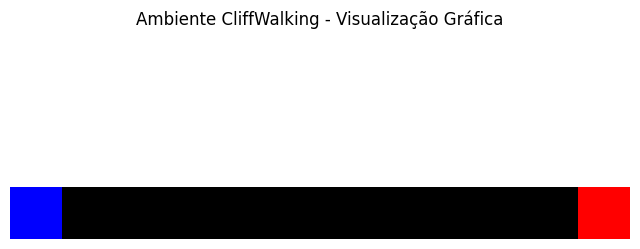

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from gym.envs.toy_text import CliffWalkingEnv

# Cria o ambiente
env = CliffWalkingEnv()
state = env.reset()

# Função de renderização gráfica
def render_cliff(state):
    n_rows, n_cols = 4, 12
    grid = np.ones((n_rows, n_cols, 3), dtype=np.uint8) * 255  # fundo branco

    # Penhasco (preto)
    grid[3, 1:11] = [0, 0, 0]
    # Início (verde)
    grid[3, 0] = [0, 255, 0]
    # Meta (vermelho)
    grid[3, 11] = [255, 0, 0]

    # Agente (azul)
    y, x = divmod(state, n_cols)
    grid[y, x] = [0, 0, 255]

    return grid

# Renderiza o estado atual
img = render_cliff(state)

# Mostra o gráfico
plt.figure(figsize=(8, 3))
plt.imshow(img)
plt.title("Ambiente CliffWalking - Visualização Gráfica")
plt.axis("off")
plt.show()


In [32]:
# plt.imshow(env.render(mode="rgb_array")) # deu erro, não tem suporte para mostrar

In [33]:
env.action_space

Discrete(4)

Neste caso move para direita e esqueda, move em 4 posições

De acordo com a documentação:

> Existem 4 ações discretas determinísticas:
>
> 0: mover para cima
>
> 1: mover para a direita
>
> 2: mover para baixo
>
> 3: mover para a esquerda

## Exiba o espaço de observações.

In [34]:
env.observation_space

Discrete(48)

De acordo com a documentação:

> O tabuleiro é uma matriz 4x12.

Isso fica evidente pela figura.

### Exiba os estados possíveis junto com suas ações, probabilidades, novos estados, recompensas e status.

In [35]:
env.P

{0: {0: [(1.0, np.int64(0), -1, False)],
  1: [(1.0, np.int64(1), -1, False)],
  2: [(1.0, np.int64(12), -1, False)],
  3: [(1.0, np.int64(0), -1, False)]},
 1: {0: [(1.0, np.int64(1), -1, False)],
  1: [(1.0, np.int64(2), -1, False)],
  2: [(1.0, np.int64(13), -1, False)],
  3: [(1.0, np.int64(0), -1, False)]},
 2: {0: [(1.0, np.int64(2), -1, False)],
  1: [(1.0, np.int64(3), -1, False)],
  2: [(1.0, np.int64(14), -1, False)],
  3: [(1.0, np.int64(1), -1, False)]},
 3: {0: [(1.0, np.int64(3), -1, False)],
  1: [(1.0, np.int64(4), -1, False)],
  2: [(1.0, np.int64(15), -1, False)],
  3: [(1.0, np.int64(2), -1, False)]},
 4: {0: [(1.0, np.int64(4), -1, False)],
  1: [(1.0, np.int64(5), -1, False)],
  2: [(1.0, np.int64(16), -1, False)],
  3: [(1.0, np.int64(3), -1, False)]},
 5: {0: [(1.0, np.int64(5), -1, False)],
  1: [(1.0, np.int64(6), -1, False)],
  2: [(1.0, np.int64(17), -1, False)],
  3: [(1.0, np.int64(4), -1, False)]},
 6: {0: [(1.0, np.int64(6), -1, False)],
  1: [(1.0, np.in

Observe que as recompensas são iguais a $-1$ ou $-100$. De acordo com a documentação:

> Cada passo resulta em recompensa $-1$, e um passo no abismo resulta em recompensa $-100$.

### Inicialize a tabela Q para armazenar a memória do treinamento, e exiba seu `shape`.

In [36]:
q_table = np.zeros([env.observation_space.n, env.action_space.n])
q_table.shape

(48, 4)

Agora, pode implementar o algoritmo Q-Learning, utilizando os mesmos parâmetros `alpha`, `gamma` e `epsilon` apresentados em aula. Como este ambiente é mais simples, pode repetir o treinamento por apenas 1000 episódios. Lembre-se de adequar o valor da recompensa na parte do script que contabiliza uma penalidade.

In [37]:
# deu erro

#import numpy as np
#import random
#from IPython.display import clear_output
#from gym.envs.toy_text import CliffWalkingEnv

# Cria o ambiente CliffWalking
#env = CliffWalkingEnv()

# Inicializa a tabela Q com zeros
# Cada linha = estado, cada coluna = ação possível
#q_table = np.zeros((env.observation_space.n, env.action_space.n))

# -----------------------------
# Parâmetros de aprendizado
# -----------------------------
alpha = 0.1      # taxa de aprendizado: quanto o agente atualiza o Q-value a cada experiência
gamma = 0.6      # fator de desconto: quanto valoriza recompensas futuras
epsilon = 0.1    # taxa de exploração: probabilidade de escolher ação aleatória (explorar)


progress = []
# -----------------------------
# Loop de treinamento
# -----------------------------
for i in range(1000):  # treina por 1000 episódios
    state = env.reset()  # reinicia o ambiente no início
    penalties, reward = 0, 0  # inicializa penalidades e recompensa acumulada
    done = False  # controla quando o episódio termina

    while not done:  # enquanto o episódio não acabar
        # -----------------------------
        # Escolha da ação (política ε-greedy)
        # -----------------------------
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()  # exploração: escolhe ação aleatória
        else:
            action = np.argmax(q_table[state])  # aproveitamento: escolhe melhor ação da tabela Q

        # -----------------------------
        # Executa a ação no ambiente
        # -----------------------------
        next_state, reward, done, info = env.step(action)

        # -----------------------------
        # Atualização da Tabela Q (Q-Learning)
        # -----------------------------
        q_old = q_table[state, action]       # Q antigo
        next_max = np.max(q_table[next_state])  # melhor Q possível no próximo estado
        # Fórmula de atualização:
        # Q(s,a) <- (1 - alpha) * Q(s,a) + alpha * (r + gamma * max(Q(s',a')))
        q_new = (1 - alpha) * q_old + alpha * (reward + gamma * next_max)
        q_table[state, action] = q_new  # salva o Q atualizado

        # Conta penalidades se o agente cair no penhasco (reward == -100)
        if reward == -100:
            penalties += 1

        # Passa para o próximo estado
        state = next_state

    # -----------------------------
    # Mostra progresso a cada 100 episódios
    # -----------------------------
    if i % 100 == 0:
        #clear_output(wait=True)
        #print('Episode:', i)
        progress.append(i)

#print("Episódios registrados:", progress)

print('Treinamento concluído')


ValueError: I/O operation on closed file

In [38]:
import numpy as np
import random
from gym.envs.toy_text import CliffWalkingEnv
import matplotlib.pyplot as plt

# Cria o ambiente CliffWalking
env = CliffWalkingEnv()

# Inicializa a tabela Q com zeros
# Cada linha = estado, cada coluna = ação possível
q_table = np.zeros((env.observation_space.n, env.action_space.n))

# -----------------------------
# Parâmetros de aprendizado
# -----------------------------
alpha = 0.1      # taxa de aprendizado
gamma = 0.6      # fator de desconto
epsilon = 0.1    # taxa de exploração

# Lista para armazenar progresso (episódios a cada 100)
progress = []

# Lista para armazenar trajetória de um episódio para visualização
trajectories = []

# -----------------------------
# Loop de treinamento
# -----------------------------
for i in range(1000):  # 1000 episódios
    state = env.reset()  # reinicia o ambiente
    penalties, reward = 0, 0
    done = False
    episode_states = [state]  # guarda os estados do episódio

    while not done:
        # política ε-greedy
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()  # explorar
        else:
            action = np.argmax(q_table[state])  # explorar conhecimento

        # executa ação
        next_state, reward, done, info = env.step(action)

        # atualização da Q-table
        q_old = q_table[state, action]
        next_max = np.max(q_table[next_state])
        q_new = (1 - alpha) * q_old + alpha * (reward + gamma * next_max)
        q_table[state, action] = q_new

        if reward == -100:
            penalties += 1

        state = next_state
        episode_states.append(state)  # adiciona estado atual ao episódio

    # registra progresso
    if i % 100 == 0:
        progress.append(i)

    # salva trajetória do último episódio para visualização
    if i == 999:  # exemplo: guarda apenas o último episódio
        trajectories = episode_states

# -----------------------------
# Treinamento concluído
# -----------------------------
# Não usamos print() para evitar erro no Jupyter
# Em vez disso, visualizamos a última trajetória


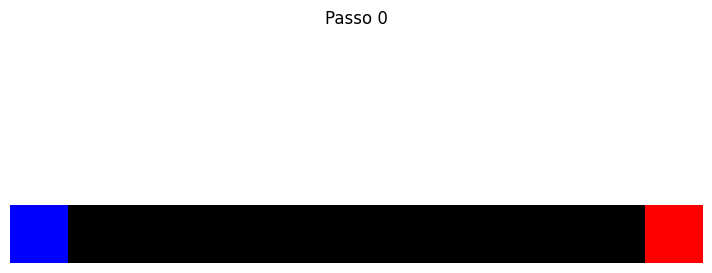

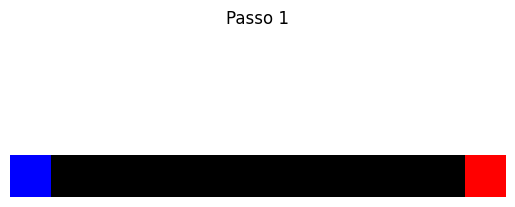

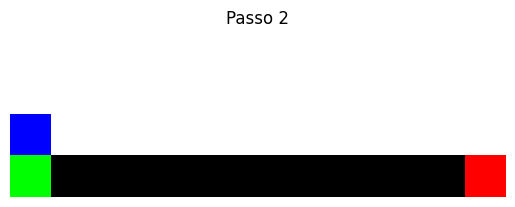

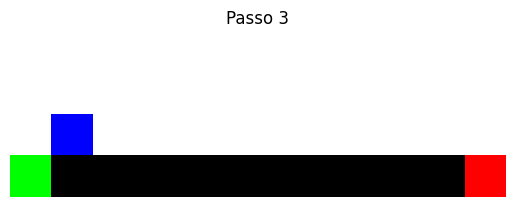

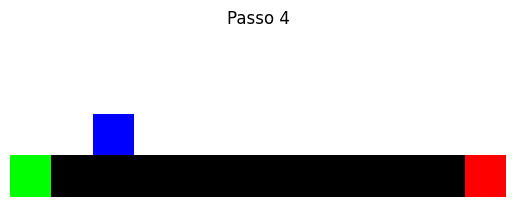

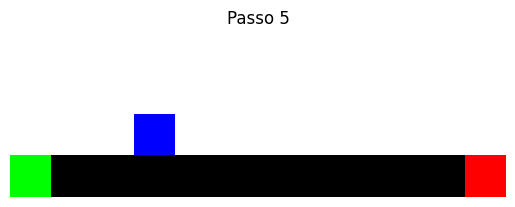

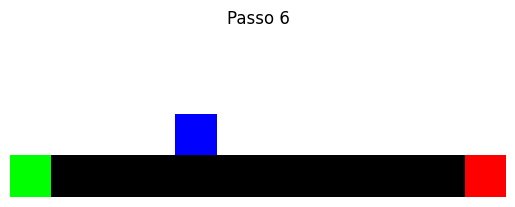

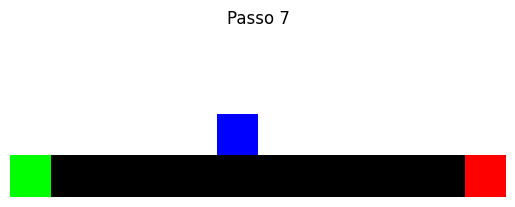

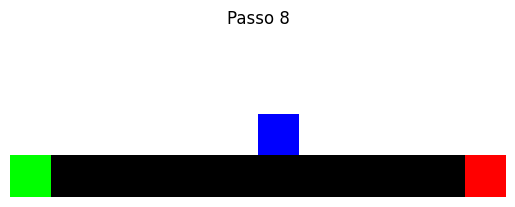

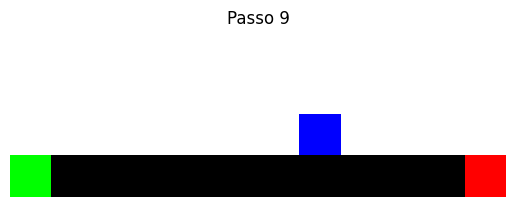

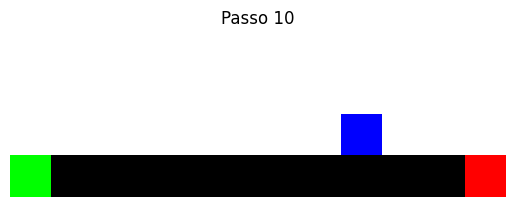

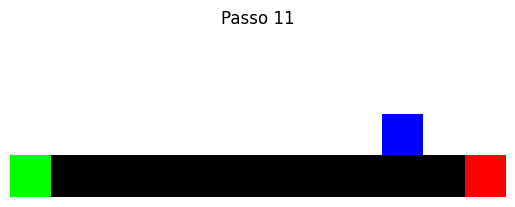

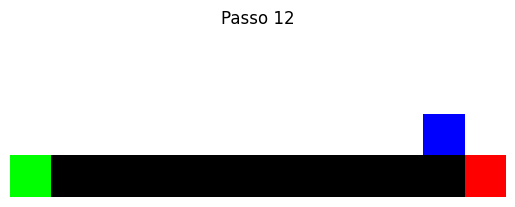

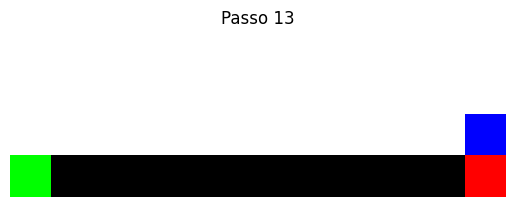

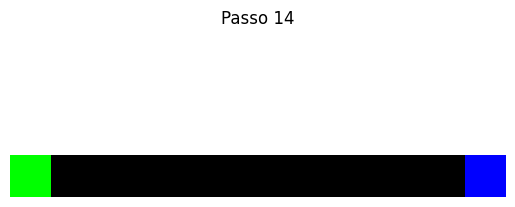

In [39]:
# Função para criar gráfico do CliffWalking
def render_cliff(state_list):
    n_rows, n_cols = 4, 12
    grid = np.ones((n_rows, n_cols, 3), dtype=np.uint8) * 255  # fundo branco

    # penhasco
    grid[3, 1:11] = [0, 0, 0]
    # início
    grid[3, 0] = [0, 255, 0]
    # meta
    grid[3, 11] = [255, 0, 0]

    imgs = []
    for s in state_list:
        img = grid.copy()
        y, x = divmod(s, n_cols)
        img[y, x] = [0, 0, 255]  # agente
        imgs.append(img)
    return imgs

# Plota cada passo do episódio
trajectory_imgs = render_cliff(trajectories)

plt.figure(figsize=(10, 3))
for idx, img in enumerate(trajectory_imgs):
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Passo {idx}")
    plt.show()
